**CURSO**: Análisis Geoespacial, Departamento de Geociencias y Medio Ambiente, Universidad Nacional de Colombia - sede Medellín <br/>
**Profesor**: Edier Aristizábal (evaristizabalg@unal.edu.co) <br />
**Credits**: The content of this notebook is taken from several sources, such as: [Ashish Arora in Medium](https://medium.com/@ashisharora2204/logistic-regression-maximum-likelihood-estimation-gradient-descent-a7962a452332). Every effort has been made to trace copyright holders of the materials used in this notebook. The author apologies for any unintentional omissions and would be pleased to add an acknowledgment in future editions.


# Regresión Binomial Negativa

Los modelos de conteo clásicos como Poisson o binomial negativa suponen que los ceros ocurren como parte del proceso natural. Pero en muchos contextos reales (como deslizamientos), hay más ceros de los que esos modelos predicen, por ejemplo:

* Celdas donde realmente no hay condiciones físicas para deslizamientos (ceros estructurales).
* Celdas donde sí podría haber, pero no ocurrieron durante el periodo observado (ceros aleatorios).

En esos casos, usamos modelos inflados en ceros, que asumen que algunos ceros provienen de un proceso separado.

El modelo ZINB combina:

* Una parte binaria (modelo logístico) que predice la probabilidad de estar en el grupo "siempre cero".
* Una parte de conteo (binomial negativa) que modela el número de eventos si no está en el grupo siempre cero.

Simularemos una serie temporal donde:

En cada unidad temporal (por ejemplo, año o mes), se espera un número de eventos (deslizamientos).

Algunas observaciones tienen ceros falsos porque no se registraron correctamente.

Ajustamos un modelo ZINB para estimar la tasa real de eventos y corregir la serie.

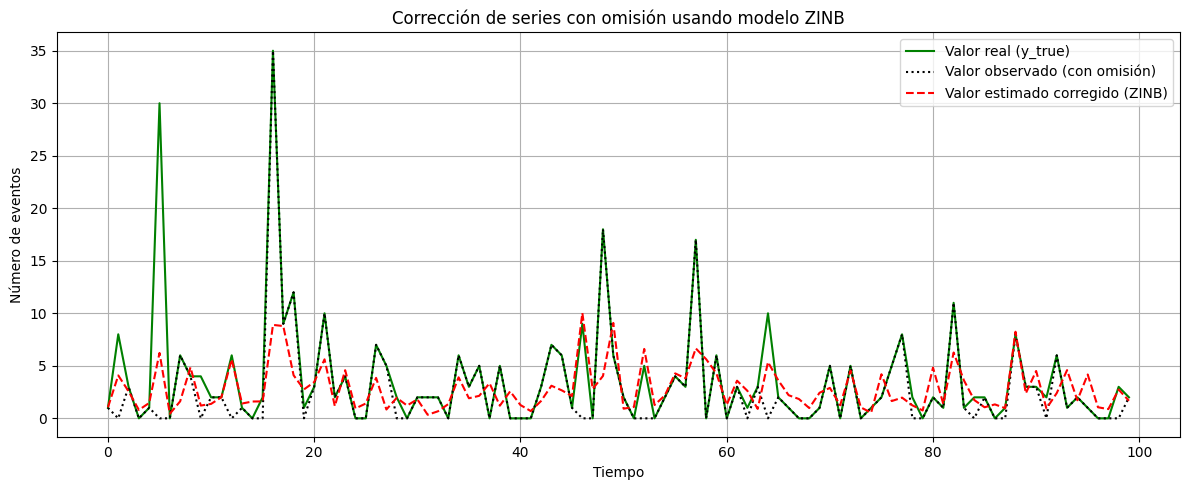

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
import statsmodels.api as sm

# 1. Simular datos reales
np.random.seed(123)
n = 100
tiempo = np.arange(n)  # ejemplo: 100 años o meses
x = np.random.normal(0, 1, n)  # predictor temporal (puede ser SPI, pendiente promedio, etc.)

# Modelo real
beta_0 = 1.0
beta_1 = 0.8
theta = 2.0
mu = np.exp(beta_0 + beta_1 * x)
from scipy.stats import nbinom
p = theta / (theta + mu)
r = theta
y_true = nbinom.rvs(r, p)

# 2. Introducir falsos ceros (subregistro): 25% de los y_true > 0 se vuelven 0
y_obs = y_true.copy()
mask = (y_true > 0) & (np.random.rand(n) < 0.25)
y_obs[mask] = 0

# 3. Preparar datos
df = pd.DataFrame({
    "tiempo": tiempo,
    "x": x,
    "y_obs": y_obs,
    "y_true": y_true,
    "falso_cero": (y_obs == 0) & (y_true > 0)
})

# 4. Ajustar modelo ZINB (modelo de corrección)
exog = sm.add_constant(df["x"])  # incluye intercepto
zinb_model = ZeroInflatedNegativeBinomialP(endog=df["y_obs"], exog=exog, exog_infl=exog, inflation="logit")
zinb_result = zinb_model.fit(method="bfgs", maxiter=100, disp=False)

# 5. Estimar media esperada corregida
df["mu_pred"] = zinb_result.predict()

# 6. Visualizar serie original, observada y corregida
plt.figure(figsize=(12, 5))
plt.plot(df["tiempo"], df["y_true"], label="Valor real (y_true)", color="green")
plt.plot(df["tiempo"], df["y_obs"], label="Valor observado (con omisión)", color="black", linestyle="dotted")
plt.plot(df["tiempo"], df["mu_pred"], label="Valor estimado corregido (ZINB)", color="red", linestyle="--")
plt.xlabel("Tiempo")
plt.ylabel("Número de eventos")
plt.title("Corrección de series con omisión usando modelo ZINB")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


La línea verde es el número real de eventos. La línea negra muestra lo que habrías observado si tuvieras errores de omisión (falsos ceros). La línea roja discontinua es lo que el modelo ZINB estima como número corregido de eventos esperados.